# Experiment #3: Logistic Regression to Predict Diabetes (PIMA Indians)

**Dataset:** Pima Indians Diabetes (`diabetes.csv`) - 768 female patients  
**Name:** Adithya Rajesh  
**Class:** R3AI  
**Roll No:** B25CTA07  
**Date:** 10-08-2026

**Objective:** Build and evaluate a logistic regression model that predicts whether a patient has diabetes (`Outcome`) from 8 diagnostic measurements.

> **Note:** The notebook must stay in the same folder as `diabetes.csv`.


## 1. Load the Dataset and Define Features (X) and Target (y)

`X` includes all available variables: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age. The target `y` is the `Outcome` column.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print('Feature set X shape:', X.shape)
print('Features:', list(X.columns))
print('Target y:', y.name, '->', y.value_counts().to_dict())

Feature set X shape: (768, 8)
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target y: Outcome -> {0: 500, 1: 268}


## 2. Split the Dataset into Training (75%) and Test (25%) Sets

`random_state=16` is used so the split is reproducible.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=16)

print('Training set :', X_train.shape)
print('Test set     :', X_test.shape)

Training set : (576, 8)
Test set     : (192, 8)


## 3. Instantiate the Logistic Regression Model, Train and Predict

`random_state=16` and `max_iter=1000` are passed to the model for reproducibility and convergence.


In [5]:
model = LogisticRegression(random_state=16, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Model trained successfully | Test predictions generated:', len(y_pred))

Model trained successfully | Test predictions generated: 192


## 4. Confusion Matrix and Heatmap

We build the confusion matrix from `y_test` (actual) and `y_pred` (predicted), then plot it as a heatmap.


In [6]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix (rows = actual, columns = predicted):')
print(cm)

Confusion matrix (rows = actual, columns = predicted):
[[116   9]
 [ 25  42]]


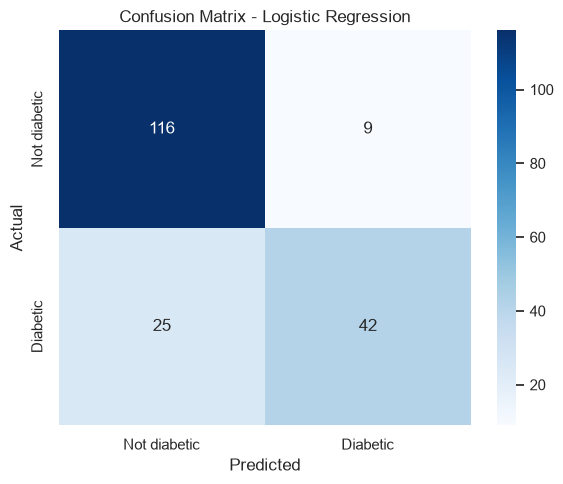

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not diabetic', 'Diabetic'],
            yticklabels=['Not diabetic', 'Diabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

## 5. Verify the Metrics: Manual Calculation vs sklearn.metrics

We first compute accuracy, precision, recall and F1-score **manually** from the confusion matrix values (TN, FP, FN, TP), then verify them with the `sklearn.metrics` functions.


In [8]:
TN, FP, FN, TP = cm.ravel()
print(f'True Negatives (TN) : {TN}')
print(f'False Positives(FP) : {FP}')
print(f'False Negatives(FN) : {FN}')
print(f'True Positives (TP) : {TP}')

True Negatives (TN) : 116
False Positives(FP) : 9
False Negatives(FN) : 25
True Positives (TP) : 42


In [9]:
manual = {
    'Accuracy' : (TN + TP) / (TN + FP + FN + TP),
    'Precision': TP / (TP + FP),
    'Recall'   : TP / (TP + FN),
    'F1-score' : 2 * TP / (2 * TP + FP + FN),
}

sklearn_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-score' : f1_score(y_test, y_pred),
}

verification = pd.DataFrame({
    'Manual calculation': [round(v, 4) for v in manual.values()],
    'sklearn.metrics'   : [round(v, 4) for v in sklearn_metrics.values()],
    'Match'             : [round(manual[k], 6) == round(sklearn_metrics[k], 6) for k in manual],
}, index=manual.keys())
display(verification)

,Manual calculation,sklearn.metrics,Match
Accuracy,0.8229,0.8229,True
Precision,0.8235,0.8235,True
Recall,0.6269,0.6269,True
F1-score,0.7119,0.7119,True


## 6. Predict for a New Patient

A new patient has the following measurements: `[2, 120, 70, 25, 80, 30.5, 0.5, 32]` (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age).


In [10]:
new_patient = np.array([[2, 120, 70, 25, 80, 30.5, 0.5, 32]])

prediction = model.predict(new_patient)[0]
probability = model.predict_proba(new_patient)[0]

print(f'Predicted class      : {prediction} ->', 'Diabetic' if prediction == 1 else 'Not diabetic')
print(f'P(not diabetic)      : {probability[0]:.4f}')
print(f'P(diabetic)          : {probability[1]:.4f}')

Predicted class      : 0 -> Not diabetic
P(not diabetic)      : 0.7617
P(diabetic)          : 0.2383


---
## Inference & Analysis

- **Accuracy:** 0.8229 - the model classifies ~82% of test patients correctly (158 of 192 in the confusion matrix).
- **Precision / Recall:** 0.8235 / 0.6269 - the model confirms healthy patients well but misses some diabetic cases (lower recall). Manual formulas and `sklearn.metrics` agree exactly.
- **New patient** `[2, 120, 70, 25, 80, 30.5, 0.5, 32]`: predicted **not diabetic** (P(diabetes) = 0.2383).

---
**End of Experiment #3.**
